In [1]:
%pip install -q pandas numpy matplotlib scipy pyyaml

Note: you may need to restart the kernel to use updated packages.


# Extended Analysis: AlphaReQ

**Research question:** *Does the shape of the AlphaReQ (α) trajectory during pre-training predict downstream multilingual performance? Specifically: does the position of the α trough (maximum self-regularization) and the rate of α decline correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)  
**Geometry source:** (`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`)

### What this notebook does
1. **Phase identification** — detects two training phases from the AlphaReQ curve: a *regularization-increasing* phase (α ↓, the model gains self-regularization) and a *regularization-decreasing* phase (α ↑, self-regularization weakens). The α trough marks the boundary between the two phases.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints.
3. **Correlation analysis** — Spearman + Pearson tests: *does the α trough position or the rate of α decline predict downstream performance?* Computed separately per task, never pooled.
4. **Plots** — AlphaReQ trajectories, phase overlays, dual-axis accuracy curves, and correlation scatter plots.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [2]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_geometry, compute_alpha_phases,
    compute_grokking,
    compute_alpha_correlations_table,
    plot_alpha_phases, plot_alpha_overlay,
    plot_alpha_correlation_scatter_combined, plot_alpha_rate_scatter_combined,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

In [3]:
MODELS = ["fuxi", "apertus"]

_PALETTE = {
    "fuxi":    {"color": "steelblue",  "marker": "o"},
    "apertus": {"color": "darkorange", "marker": "s"},
}

data = {}
for m in MODELS:
    cfg = load_config(m)
    data[m] = {
        "cfg":    cfg,
        "color":  _PALETTE[m]["color"],
        "marker": _PALETTE[m]["marker"],
    }
    print(f"[{m}] {cfg['model_label']}  |  Layer: {cfg['layer']}  |  Aggregation: {cfg['aggregation']}")

[fuxi] FuxiTranyu-8B  |  Layer: layer_29  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_31  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — spectral geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for AlphaReQ phase identification and trajectory plots. The working slice (`layer_29` / `layer_31`, `agg=last`) gives one geometry value per (checkpoint, language) pair across the full training run.

- **`fuxi_fine_wiki_merged.csv` / `apertus_fine_wiki_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Used for grokking detection, correlation analysis, and overlay plots.

In [4]:
for m in MODELS:
    cfg = data[m]["cfg"]
    df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(
        cfg["rankme_csv"], cfg["layer"], cfg["aggregation"])
    df_eval, eval_available = load_eval_data(cfg["merged_csv"])
    data[m].update({
        "df_rankme":       df_rankme,
        "df_layer":        df_layer,
        "checkpoints_all": checkpoints_all,
        "token_counts":    token_counts,
        "langs_sorted":    langs_sorted,
        "df_eval":         df_eval,
        "eval_available":  eval_available,
    })
    print()

Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_29, agg=last → 798 rows
Loaded eval: 741 records — 2 task(s), 57 checkpoint(s)

Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_31, agg=last → 616 rows
Loaded eval: 572 records — 2 task(s), 44 checkpoint(s)



## AlphaReQ Trajectories

The table below summarises key AlphaReQ (α) phase metrics per language, derived from the activation matrix eigenvalue spectrum at the working layer:

- **trough (B)** — token count where α reaches its global minimum (point of maximum self-regularization). All languages in Apertus trough at the very first observed checkpoint (210B); in Fuxi the trough varies across languages (157B–531B).
- **reg-increasing onset (B)** — token count where α starts declining; for Fuxi, always the first observed checkpoint (10B). `NaN` for Apertus (α already troughed before the first checkpoint).
- **rate of α decline (α/B)** — how steeply α drops per billion tokens during the regularization-increasing phase. `NaN` for Apertus.
- **reg-decreasing onset (B)** — equal to the trough; where α begins rising again.
- **reg-decreasing duration (B)** — length of the α-rising phase.

In [5]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_alpha_phases = compute_alpha_phases(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_alpha_phases"] = df_alpha_phases

    display_cols = {
        "language":                       "language",
        "trough_tokens":                  "trough (B)",
        "reg_increasing_onset_tokens":    "reg-increasing onset (B)",
        "reg_increasing_rate":            "rate of α decline (α/B)",
        "reg_decreasing_onset_tokens":    "reg-decreasing onset (B)",
        "reg_decreasing_duration_tokens": "reg-decreasing duration (B)",
    }
    print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
    print(df_alpha_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))


── FuxiTranyu-8B ────────────────────────────────────────
  language  trough (B)  reg-increasing onset (B)  rate of α decline (α/B)  reg-decreasing onset (B)  reg-decreasing duration (B)
    Arabic       531.0                      10.0                 0.000201                     531.0                         62.0
   Chinese       325.0                      10.0                 0.000243                     325.0                        268.0
   English       325.0                      10.0                 0.000210                     325.0                        268.0
   Finnish       189.0                      10.0                 0.000256                     189.0                        404.0
    French       325.0                      10.0                 0.000201                     325.0                        268.0
    German       241.0                      10.0                 0.000268                     241.0                        352.0
     Hindi       531.0                

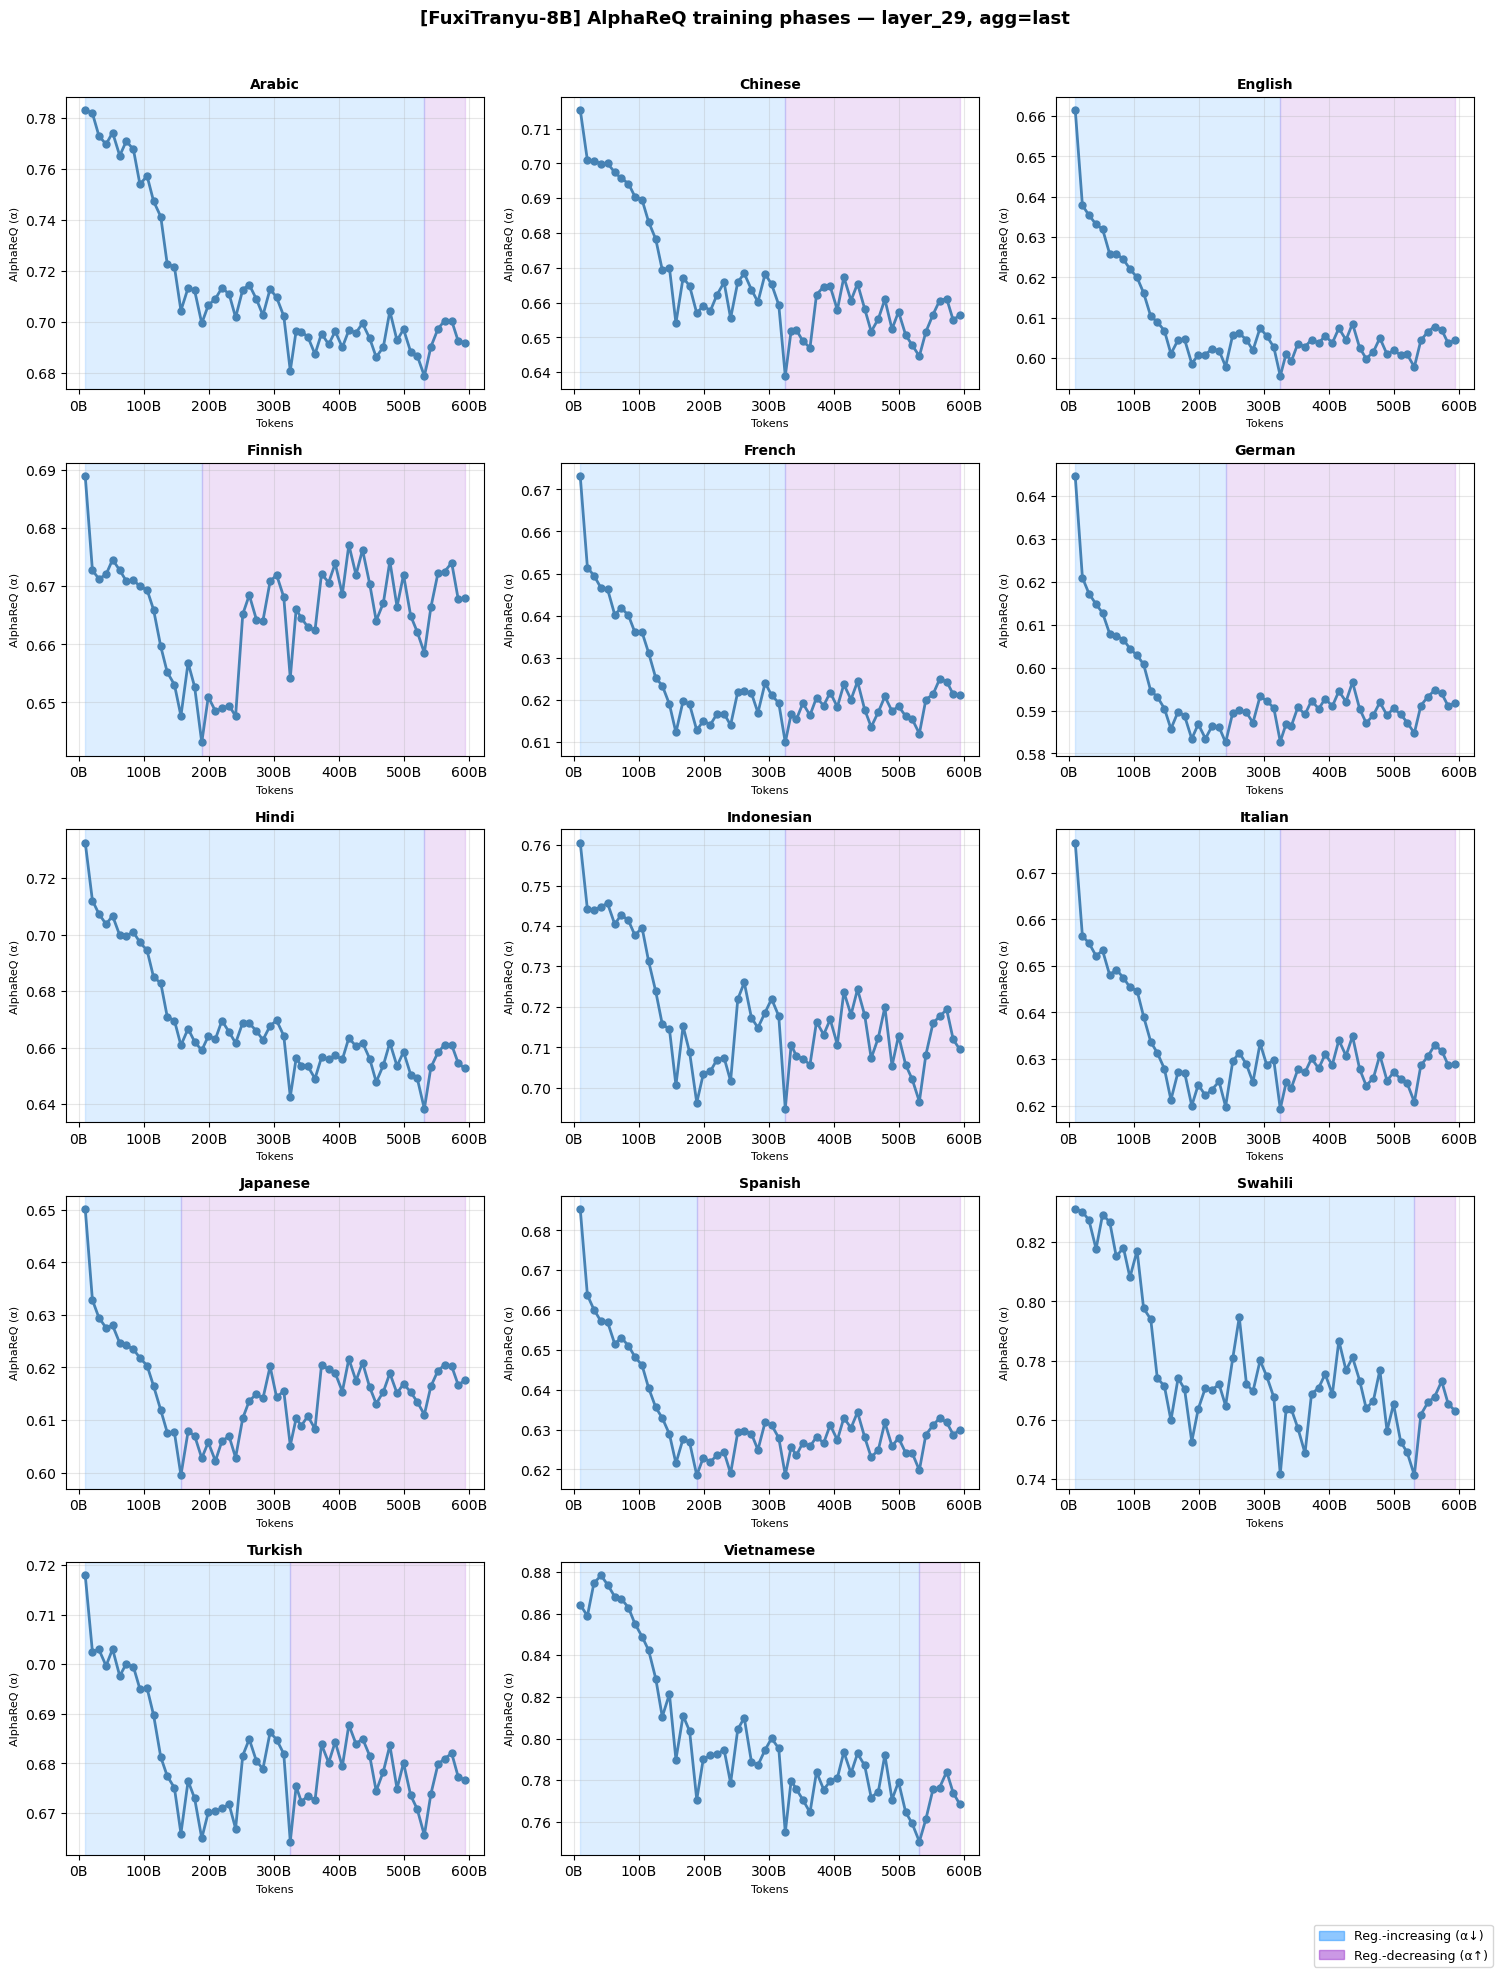

Saved: plots/alpha_phases_fuxi.png


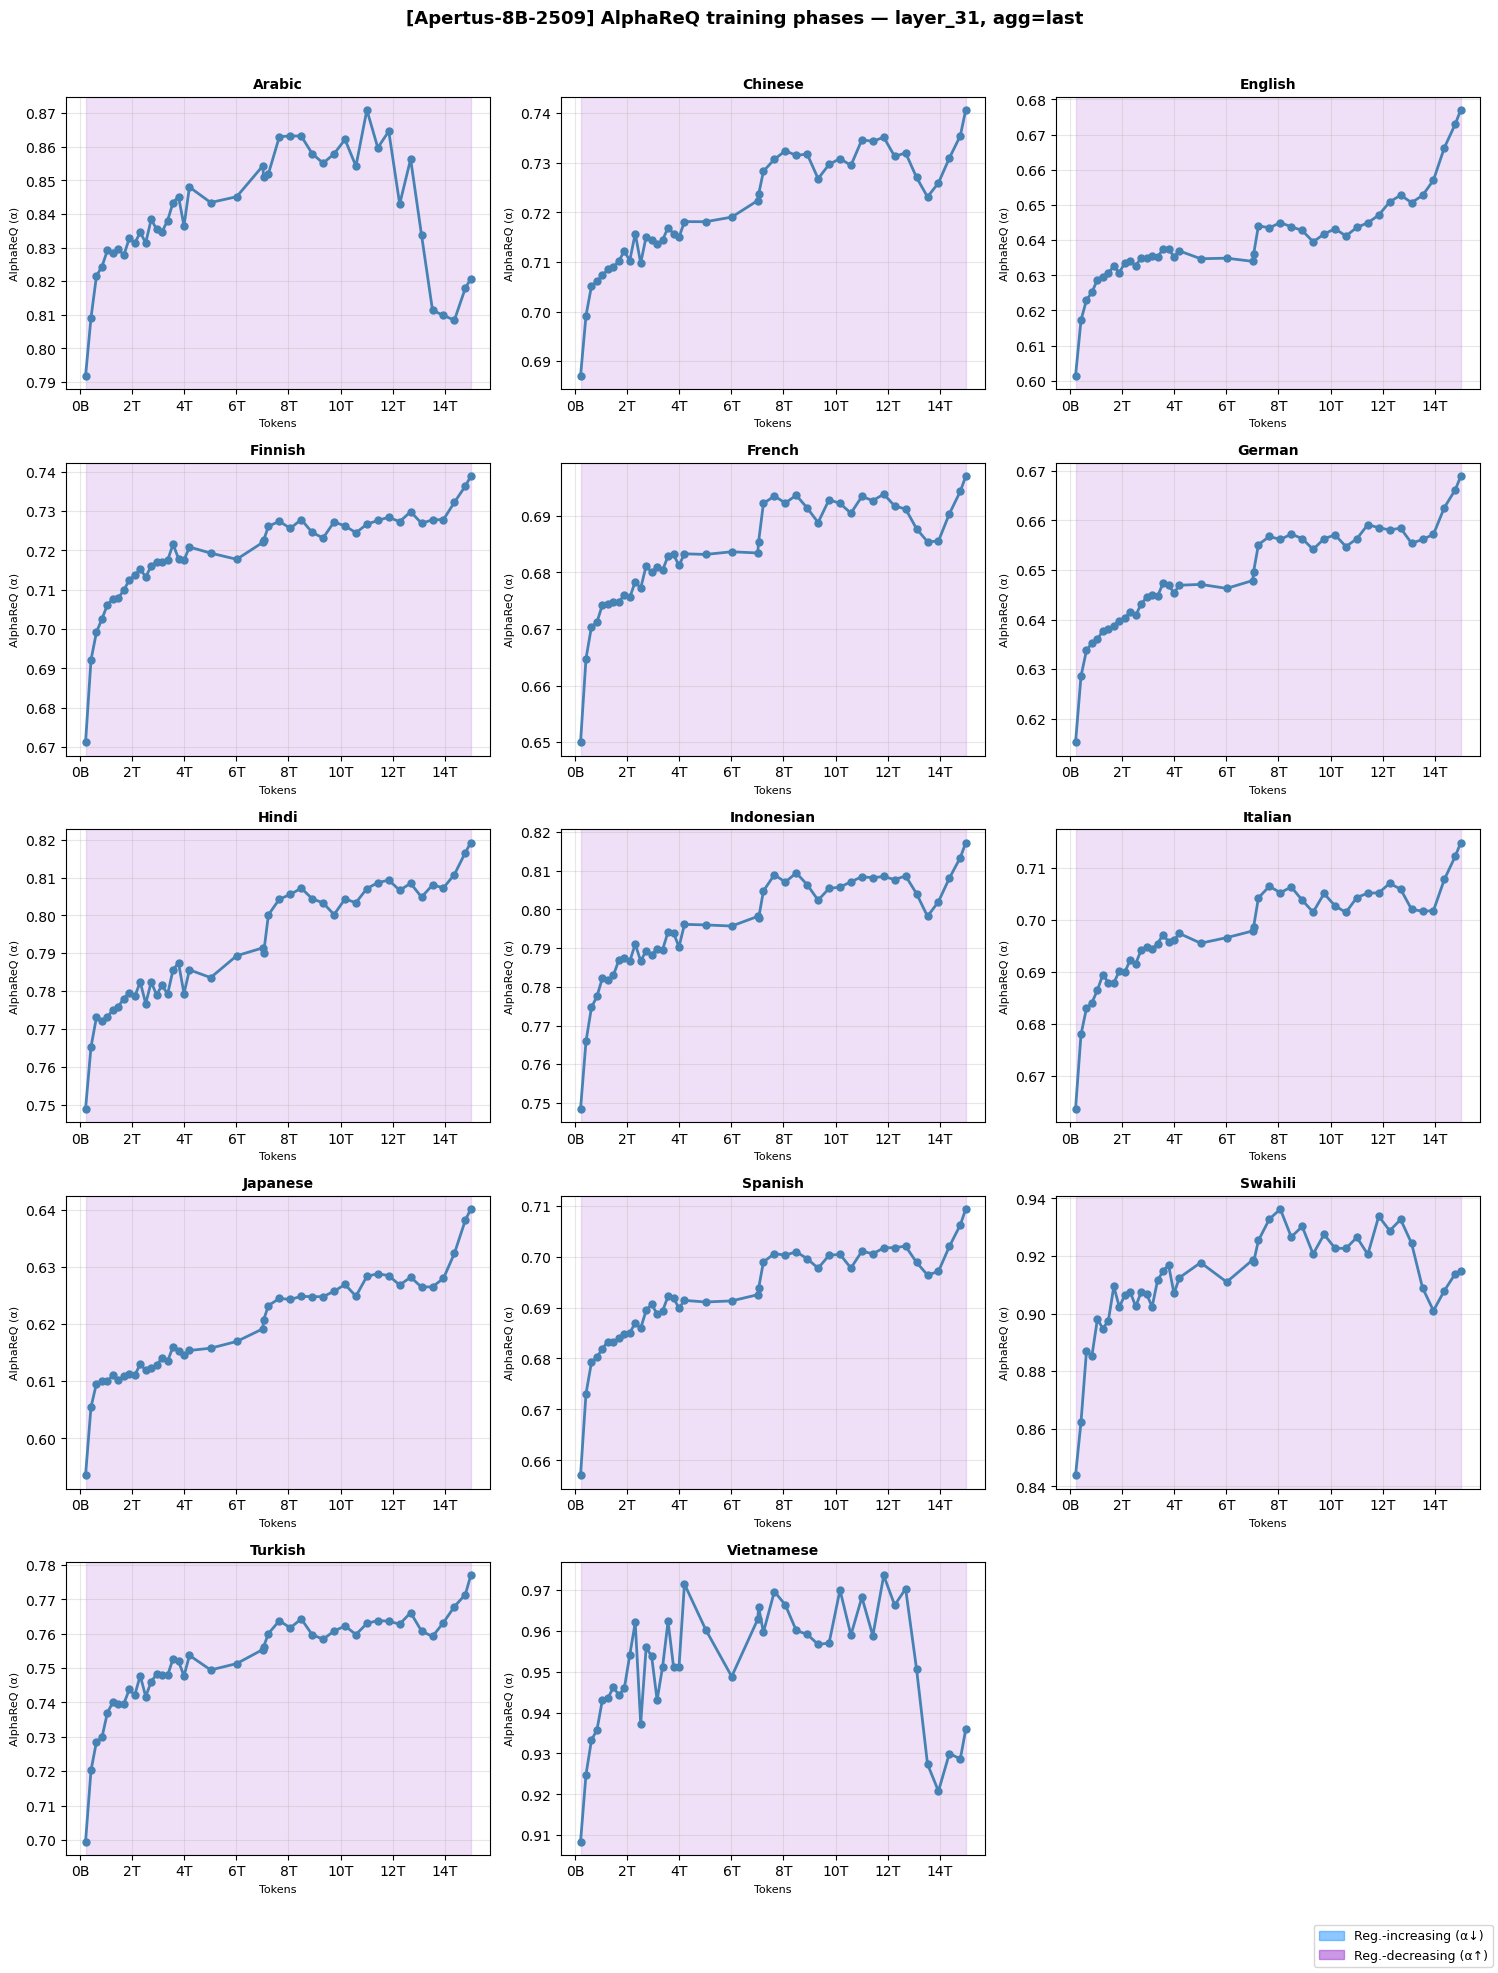

Saved: plots/alpha_phases_apertus.png


In [6]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    plot_alpha_phases(d["df_layer"], d["df_alpha_phases"], d["checkpoints_all"], d["token_counts"],
                      d["langs_sorted"], cfg["model_label"], cfg["layer"], cfg["aggregation"],
                      cfg["plots_dir"], model_key=m)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task. Grokking onset and peak accuracy serve as the outcome variables for the AlphaReQ correlation analysis.

- **grokking_tokens (B)** — token count at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all checkpoints.
- **random_chance** — baseline accuracy (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means the model never exceeded the threshold, or only crossed it once without 2 consecutive checkpoints.

In [7]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_geometry = compute_geometry(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_geometry"] = df_geometry
    if d["eval_available"]:
        df_grokking = compute_grokking(
            d["df_eval"], cfg["task_languages"], cfg["random_chance"],
            threshold=cfg["grokking_threshold"],
            min_consecutive=cfg["grokking_min_consec"])
        d["df_grokking"] = df_grokking
        display_cols = {
            "task":            "task",
            "language":        "language",
            "grokking_tokens": "grokking onset (B)",
            "peak_tokens":     "peak (B)",
            "peak_accuracy":   "peak accuracy",
            "random_chance":   "random chance",
        }
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
    else:
        d["df_grokking"] = pd.DataFrame()
        print(f"[{m}] No eval data — run submit_eval.sh + merge_results.py first.")


── FuxiTranyu-8B ────────────────────────────────────────
  task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
m_mmlu    English                 NaN     115.0       0.272590           0.25
m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
m_mmlu     German                 NaN     199.0       0.274928           0.25
m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
m_mmlu    Italian                 NaN     415.0       0.275818           0.25
m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
 xcopa    Chinese               325.0     426.0       0.664000           0.50
 xcopa    Italian               241.0     520.0       0.718000           0.50
 xcopa Vietnamese               126.0     436.0       0.736000           0.50
 xcop

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language. Each panel shows two y-axes:

- **Left axis (blue)** — AlphaReQ (α) trajectory across all checkpoints.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

Shaded regions mark the two α phases (blue = regularization-increasing, purple = regularization-decreasing). The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A purple vertical dashed line marks the grokking onset for that language — absent when grokking was not detected.

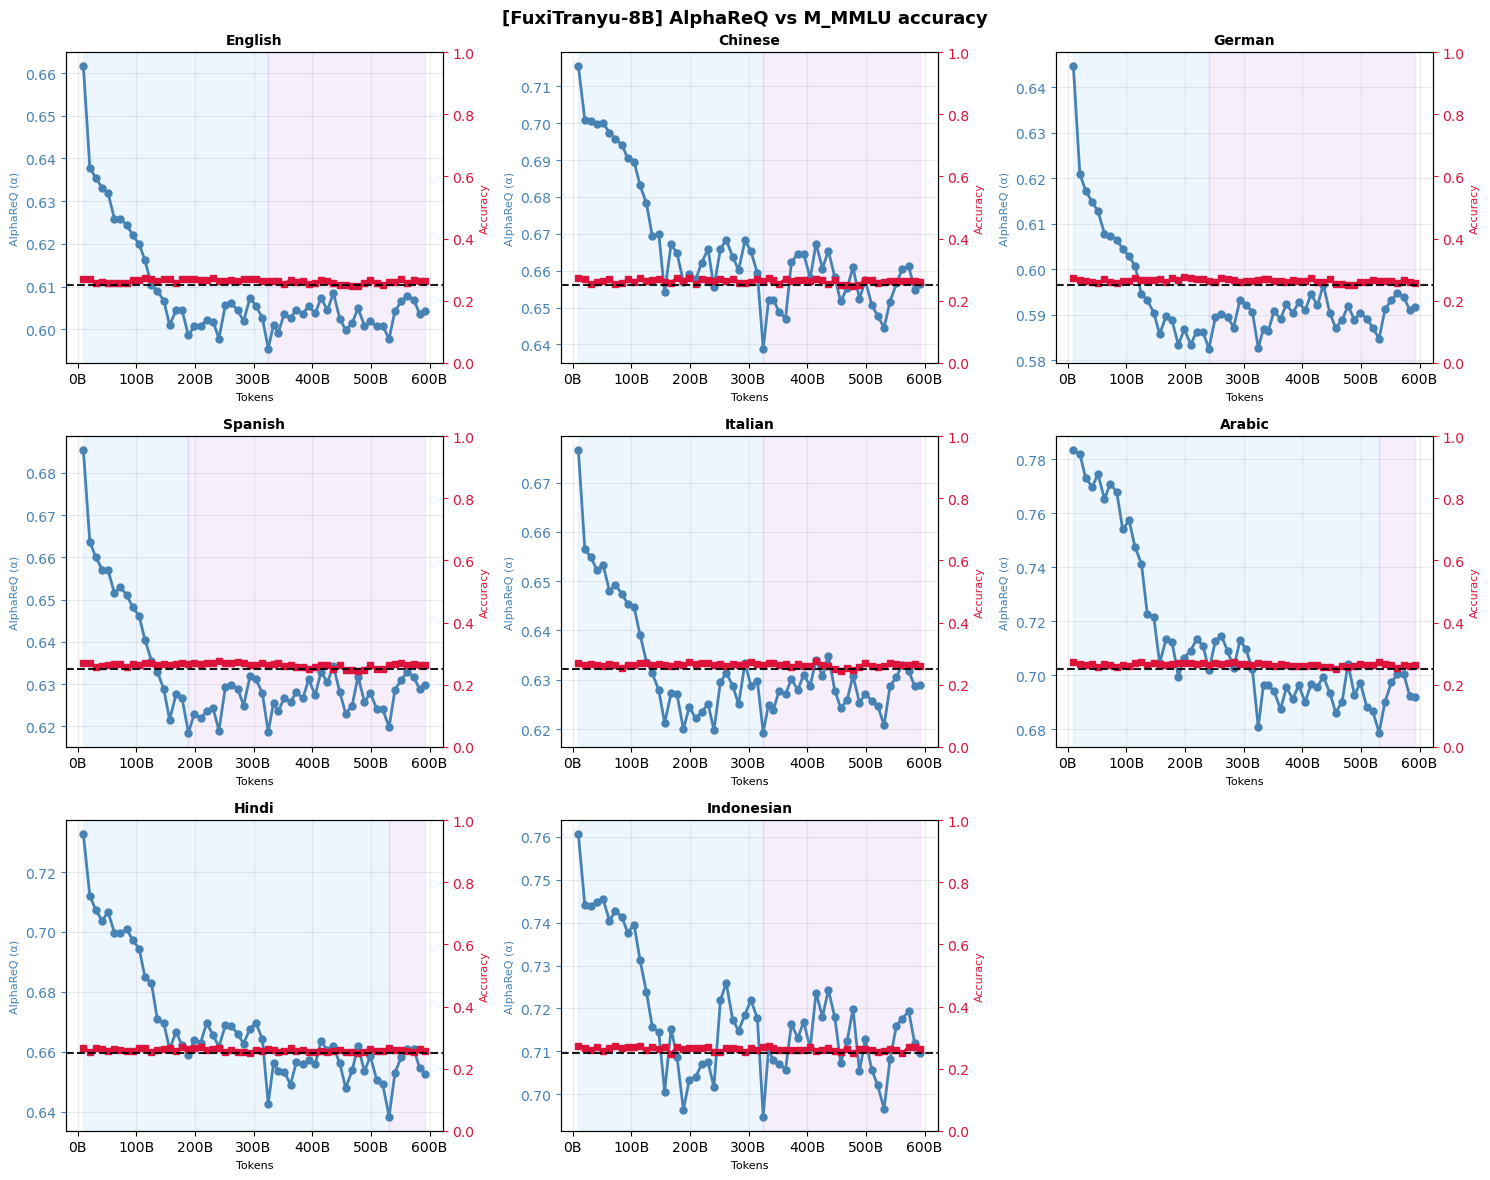

Saved: plots/alpha_overlay_m_mmlu_fuxi.png


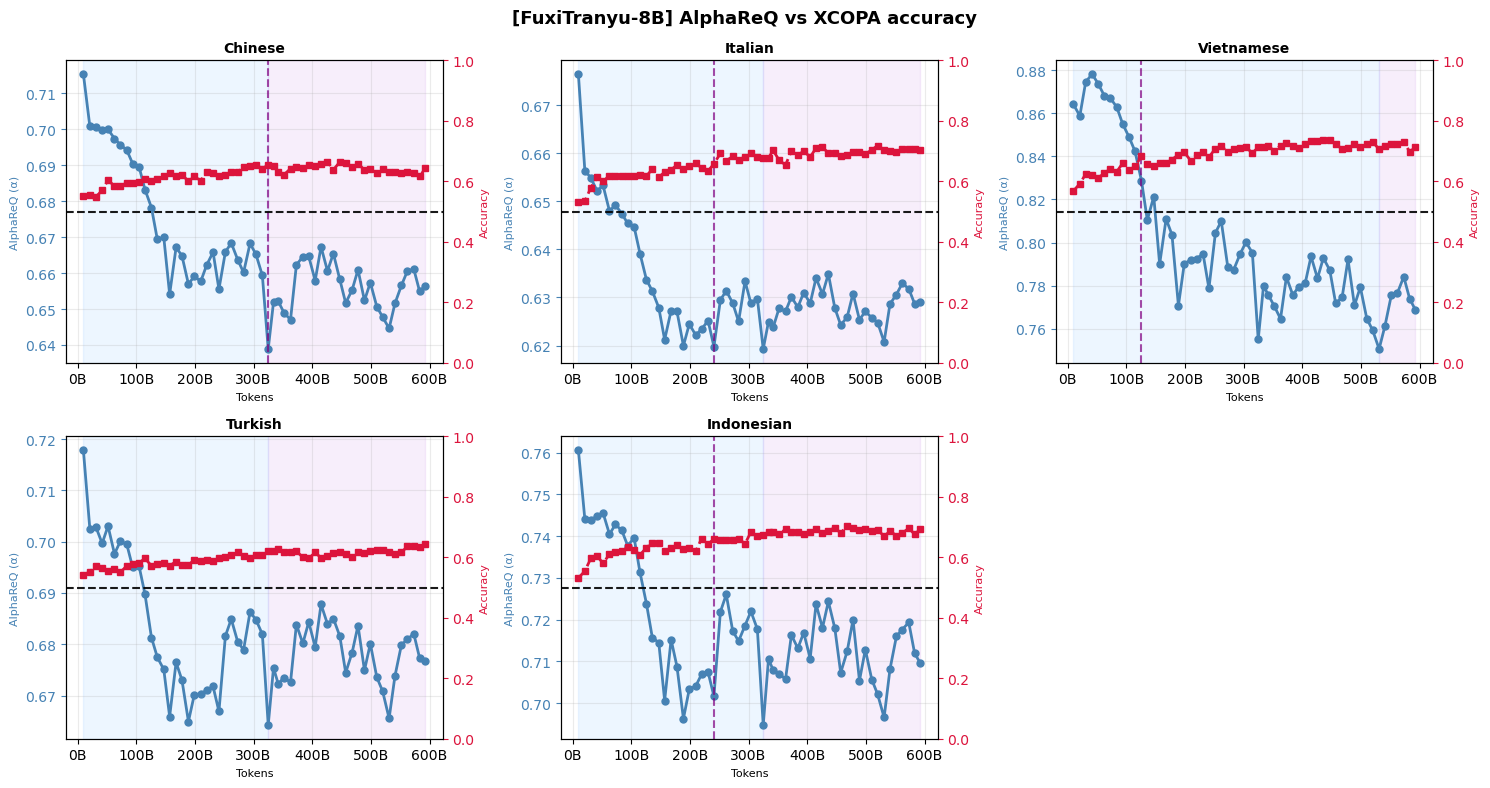

Saved: plots/alpha_overlay_xcopa_fuxi.png


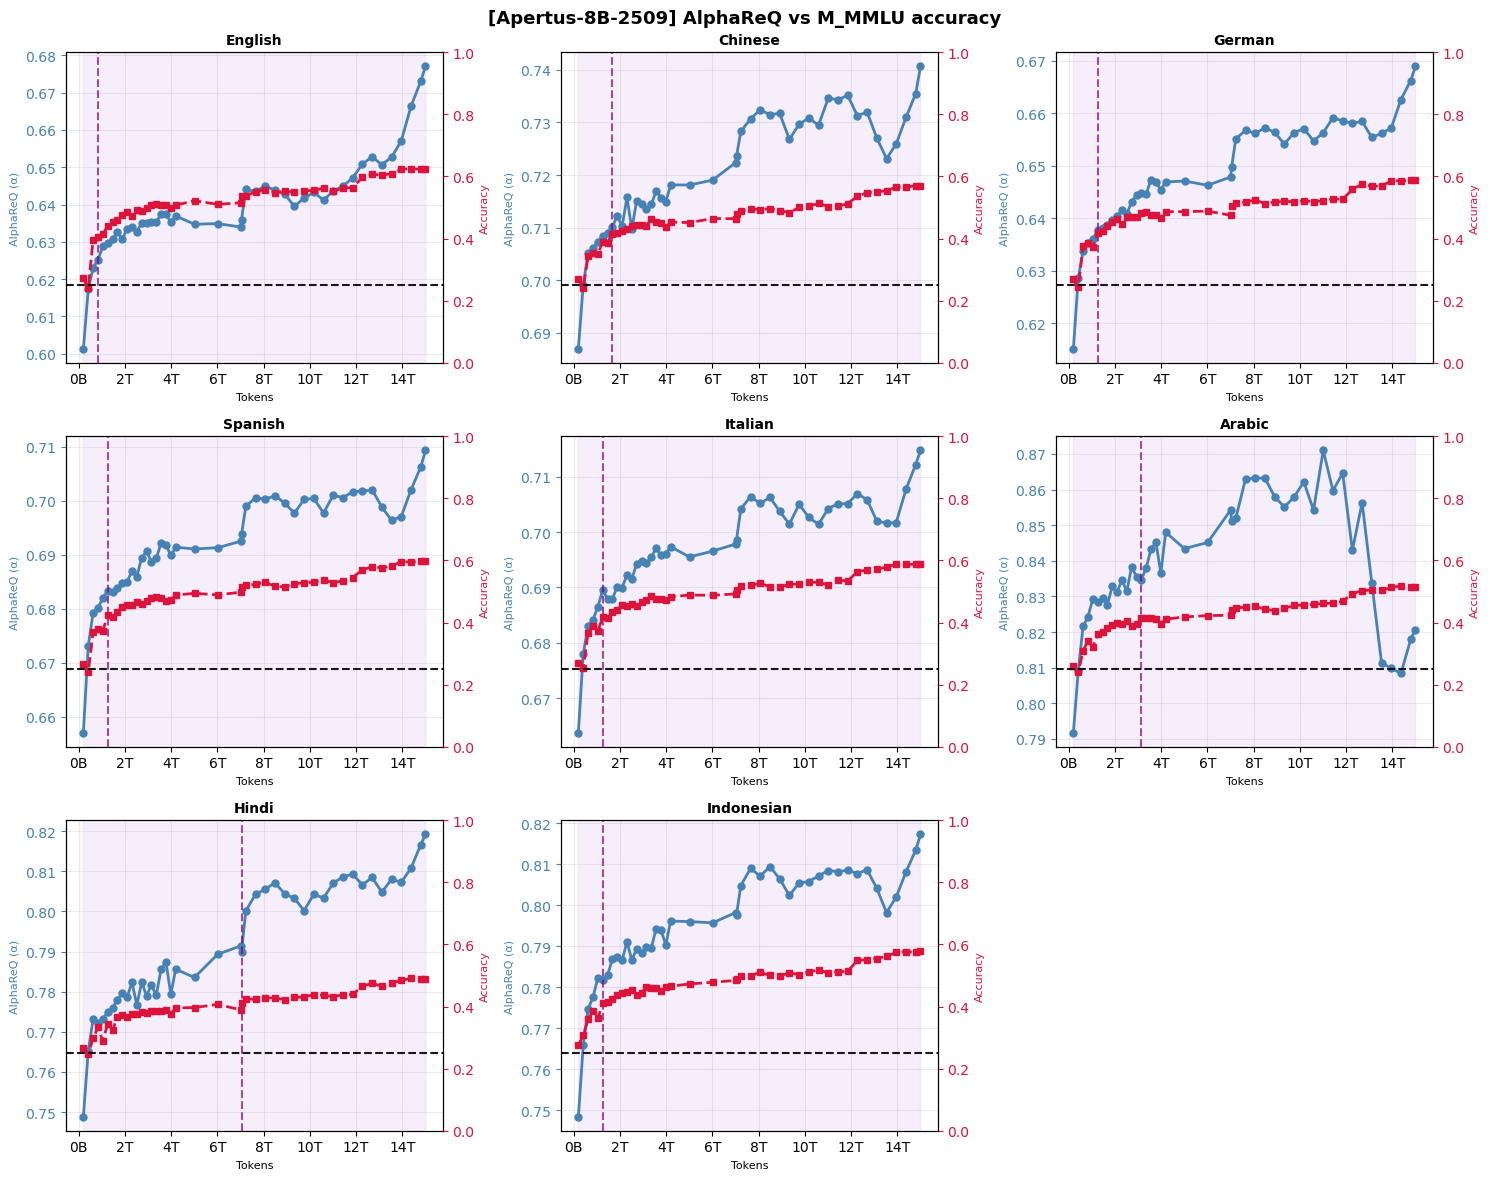

Saved: plots/alpha_overlay_m_mmlu_apertus.png


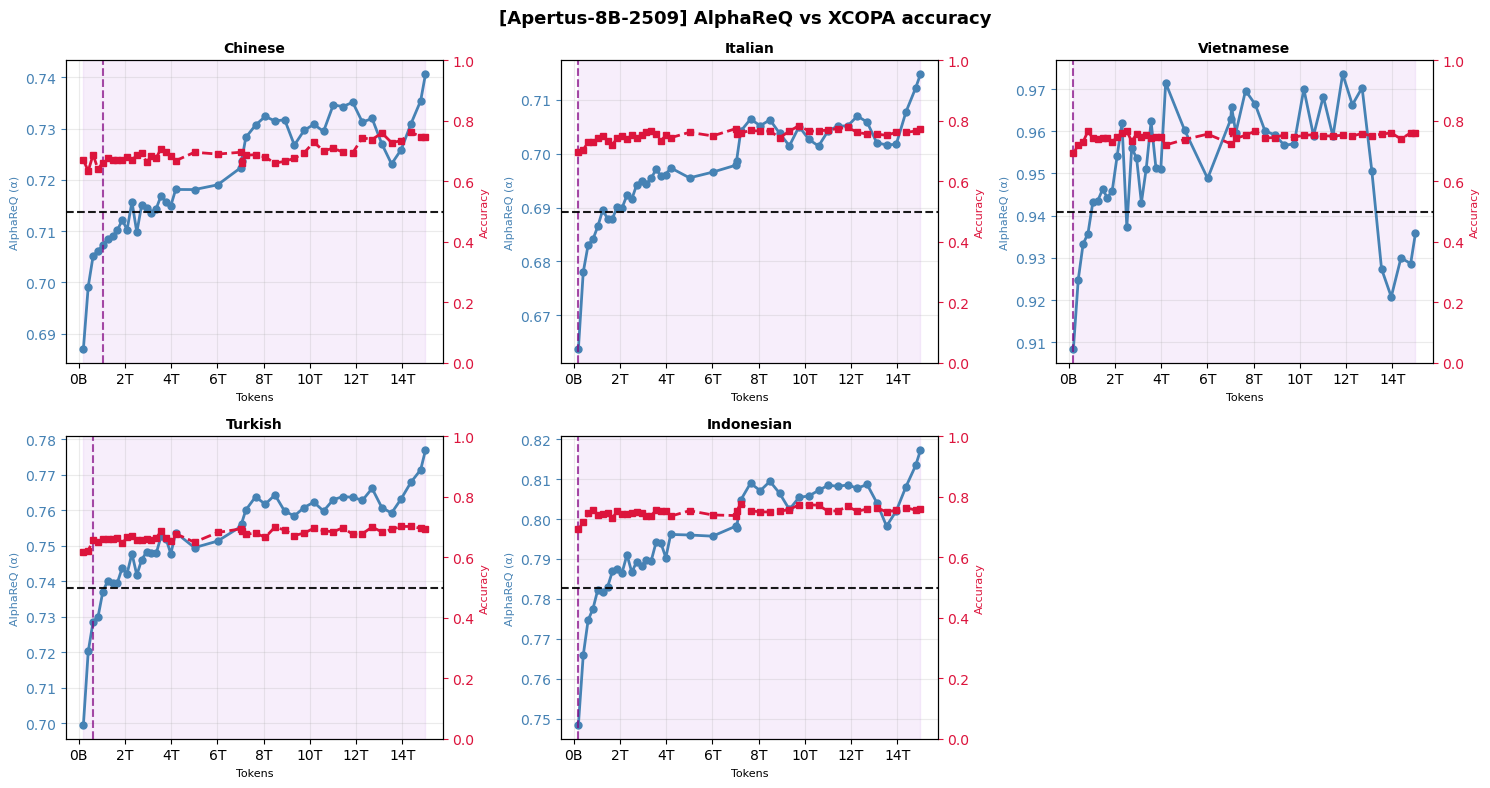

Saved: plots/alpha_overlay_xcopa_apertus.png


In [8]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        plot_alpha_overlay(d["df_eval"], d["df_layer"], d["df_alpha_phases"], d["df_grokking"],
                           cfg["task_languages"], cfg["random_chance"],
                           d["checkpoints_all"], d["token_counts"], d["langs_sorted"],
                           cfg["model_label"], cfg["plots_dir"], model_key=m)
    else:
        print(f"[{m}] Skipping AlphaReQ overlay plots — run evaluate.py first.")

## Correlation Analysis

Tests whether AlphaReQ geometry predicts downstream performance. Two predictors are tested against two outcomes, separately per task (m-MMLU / XCOPA), never pooled:

- **Reg.-decreasing onset (B)** — position of the α trough; the checkpoint where self-regularization is at its peak.
- **Rate of α decline (α/B)** — how steeply α falls per billion tokens during the regularization-increasing phase.

Outcomes:
- **Grokking onset (B)** — when accuracy first crosses the threshold.
- **Peak accuracy** — highest accuracy across all checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported.

In [9]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_grokking"].empty:
        df_alpha_correlations = compute_alpha_correlations_table(d["df_grokking"], d["df_alpha_phases"])
        d["df_alpha_correlations"] = df_alpha_correlations
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_alpha_correlations.to_string(index=False))
    else:
        d["df_alpha_correlations"] = pd.DataFrame()
        print(f"[{m}] Skipping AlphaReQ correlation analysis — no eval data available.")


── FuxiTranyu-8B ────────────────────────────────────────
  task             predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu Reg.-decreasing onset (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu Reg.-decreasing onset (B)      Peak accuracy            8     -0.6385      0.0884    -0.6867     0.0599
m_mmlu   Rate of α decline (α/B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu   Rate of α decline (α/B)      Peak accuracy            8      0.4286      0.2894     0.5585     0.1502
 xcopa Reg.-decreasing onset (B) Grokking onset (B)            4     -0.8165      0.1835    -0.8748     0.1252
 xcopa Reg.-decreasing onset (B)      Peak accuracy            5      0.7071      0.1817     0.6263     0.2583
 xcopa   Rate of α decline (α/B) Grokking onset (B)            4      0.3162      0.6838     0.3053     0.6947
 xcopa   Rate of α decline (α/B)      Peak accuracy  

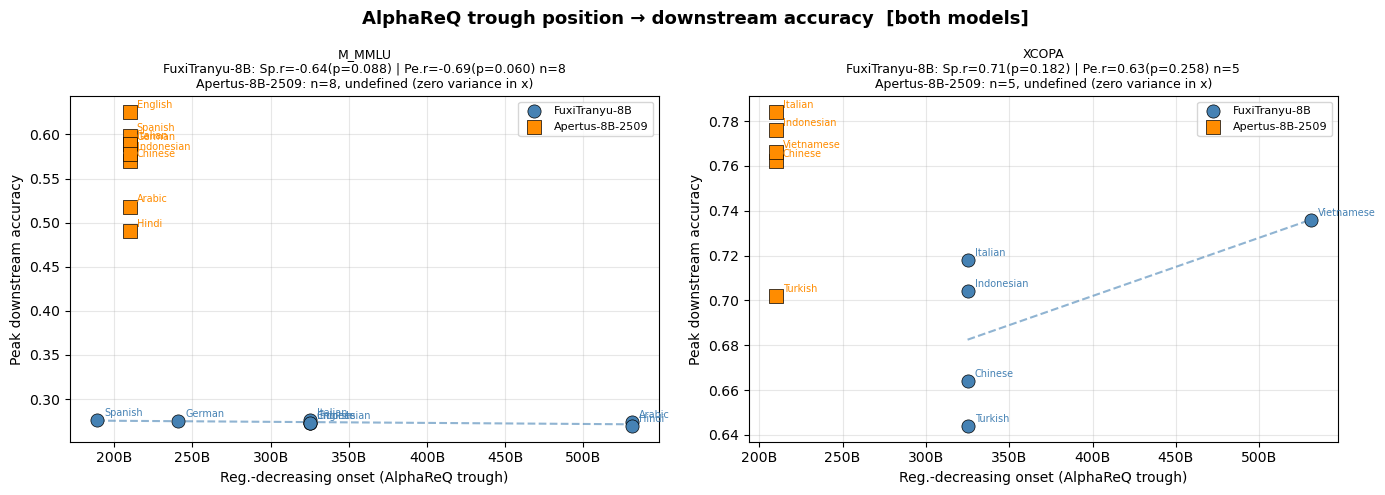

Saved: plots/alpha_correlation_scatter.png


In [10]:
alpha_models_data = [
    {
        "label":           data[m]["cfg"]["model_label"],
        "df_grokking":     data[m].get("df_grokking",     pd.DataFrame()),
        "df_alpha_phases": data[m].get("df_alpha_phases", pd.DataFrame()),
        "color":           data[m]["color"],
        "marker":          data[m]["marker"],
    }
    for m in MODELS if data[m]["eval_available"]
]
if alpha_models_data:
    plot_alpha_correlation_scatter_combined(alpha_models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping AlphaReQ correlation scatter — no eval data available.")

**FuxiTranyu-8B:** The rate of α decline shows no significant relationship with grokking onset (Sp r=+0.32, p=0.68, n=4) or peak accuracy (Sp r=+0.30, p=0.62, n=5). The correlation is small and not significant for this model and dataset.

**Apertus-8B-2509:** The α trough falls at the very first observed checkpoint (210B) for all languages, so the rate of α decline cannot be computed — this panel contains no Apertus points. See the AlphaReQ Findings section below.

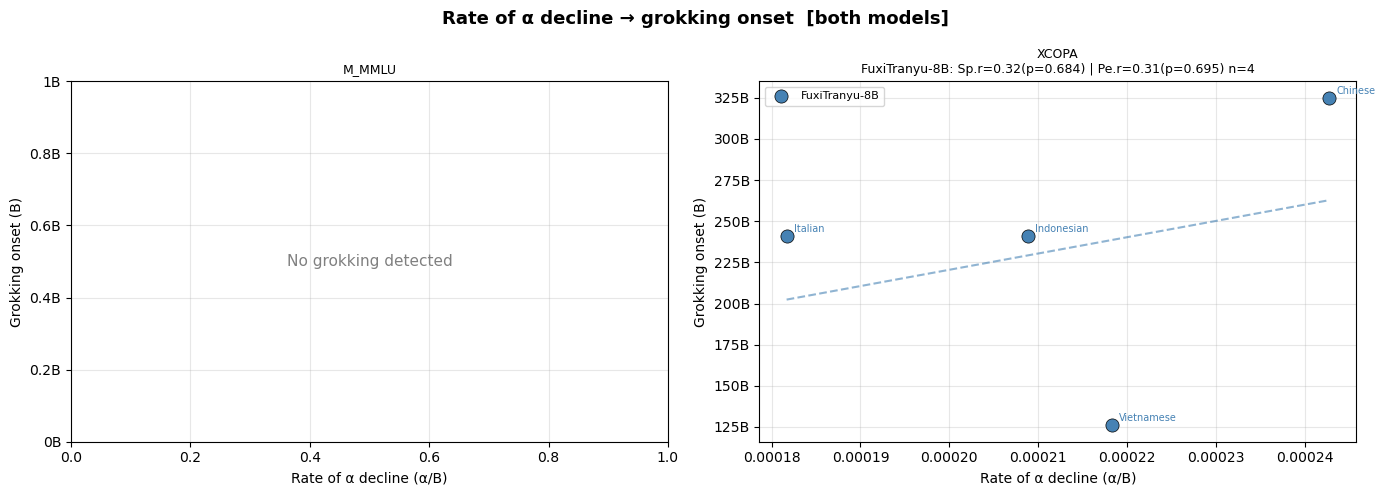

Saved: plots/alpha_rate_scatter.png


In [11]:
if alpha_models_data:
    plot_alpha_rate_scatter_combined(alpha_models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping AlphaReQ rate scatter — no eval data available.")

## AlphaReQ Findings

### FuxiTranyu-8B

**Phase structure (AlphaReQ, all 14 languages)**

- Both phases are present in every language: α falls to a trough then rises, confirming the regularization-increasing → regularization-decreasing pattern throughout training.
- The α trough position varies across languages (157B–531B), unlike RankMe where all languages peak at 10B. Japanese reaches the trough earliest (157B), Finnish and Spanish next (189B), most languages cluster around 241–325B, while Arabic, Hindi, Swahili, and Vietnamese trough latest (531B) — mirroring the resource-level ordering seen in RankMe.
- The rate of α decline also varies: Japanese and Spanish fastest (0.000344–0.000373 α/B), Turkish and Swahili slowest (0.000170–0.000173 α/B).

**Correlation analysis**

- **m-MMLU:** Reg-decreasing onset (trough position) shows a marginal negative correlation with peak m-MMLU accuracy (Sp r=−0.639, p=0.088, n=8): languages with an earlier trough tend to score higher. This does not reach significance and should be interpreted with caution.
- **XCOPA:** Reg-decreasing onset shows a strong trend with grokking onset (Sp r=−0.817, p=0.183, n=4): languages reaching peak regularization earlier also tend to grok earlier — an intuitive result, but n=4 is too small to reach significance. Rate of α decline shows no relationship with grokking onset (Sp r=+0.32, p=0.68) or peak accuracy.
- **No AlphaReQ correlation reaches statistical significance for this model.** The trough position is a useful ordering variable but does not provide independent predictive power beyond the resource-level axis already captured by RankMe.

---

### Apertus-8B-2509

**Phase structure (AlphaReQ, all 14 languages)**

- The α trough falls at exactly 210B (the first observed checkpoint) for all 14 languages — the regularization-increasing phase (α declining from training start to the trough) is entirely unobservable with this checkpoint grid. We only see the regularization-decreasing phase (α rising from 210B onward).
- This is the AlphaReQ analogue of Fuxi's RankMe situation: just as Fuxi's RankMe had already peaked by the first checkpoint, Apertus's α has already troughed.
- Because no pre-trough data exists, the rate of α decline cannot be computed for any language. All AlphaReQ timing correlations for Apertus are undefined.
- **AlphaReQ analysis is uninformative for Apertus** with the current checkpoint resolution. Earlier checkpoints (< 210B) would be needed to observe the regularization-increasing phase and compute meaningful rates.